<a href="https://colab.research.google.com/github/alimoorreza/CS181-fall26-notes/blob/main/day08_resnet_dissection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS181: Computer Vision, Fall 2026

Thursday, September 17, 2026

📆 [Course Schedule](https://analytics.drake.edu/~reza/teaching/cs181_fall26/cs181_schedule.html) | 📜 [Syllabus](https://analytics.drake.edu/~reza/teaching/cs181_fall26/cs181_syllabus_fall26.pdf)


In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


##**Utility functions**
- Load the mapping between the **class indices and class names** for the 1,000 ImageNet categories.
- Display the **top-5 or top-10 predicted classes** from the 1,000 ImageNet categories.


In [3]:
import torch
import torch.nn as nn
import torchvision
from torchvision import models, transforms, datasets

import sys
import os
import scipy.io

import json
import PIL
import numpy as np
import matplotlib.pyplot as plt

import requests
url = "https://analytics.drake.edu/~reza/teaching/cs181_fall26/datasets/imagenet_1000_classes.json"

response = requests.get(url)
response.raise_for_status()
label_map = response.json()
print(label_map)

def display_prediction(output_prob, label_map, how_many=10):
    print(f"label map: {label_map}")
    '''
    topk          = torch.topk(output_prob, k=how_many)
    topk_prob     = topk.values[0]
    topk_indices  = topk.indices[0]
    '''

    topk            = torch.topk(output_prob, k=how_many, dim=1)
    topk_prob       = topk.values[0]
    topk_indices    = topk.indices[0]


    if device == 'cuda':
        topk_indices  = topk_indices.data.cpu().numpy()
    else:
        topk_indices  = topk_indices.data.numpy()

    print(f"top{how_many}_classes are as follow: \n{topk_indices}")
    labels        = "{:75s}".format("predicted label")
    prob          = "{}".format("probability")
    print("\n{:75s}".format("--------------------------------------------------------------------------------------\n"), labels, prob,"\n{:75s}".format("--------------------------------------------------------------------------------------"))

    for i in range(how_many):
        labels  = label_map[str(topk_indices[i])]
        labels  = "{:75s}".format(labels)
        prob    = "{:.4f}".format(float(topk_prob[i]))
        print(labels, prob)

    print("{:75s}".format("--------------------------------------------------------------------------------------"))


def get_imagenet_mean_std_normalized():
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    return mean, std

TEST_IMAGE_DIR  = '/content/drive/MyDrive/cs181_fall26/module_3_classification/images/'
image_name_list = ['random_dog1.jpg',
                   'random_dog2.jpg',
                   'random_cat1.jpg',
                   'random_cat2.jpg',
                   'random_bike1.jpg'
                   ]


{'0': 'tench, Tinca tinca', '1': 'goldfish, Carassius auratus', '2': 'great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias', '3': 'tiger shark, Galeocerdo cuvieri', '4': 'hammerhead, hammerhead shark', '5': 'electric ray, crampfish, numbfish, torpedo', '6': 'stingray', '7': 'cock', '8': 'hen', '9': 'ostrich, Struthio camelus', '10': 'brambling, Fringilla montifringilla', '11': 'goldfinch, Carduelis carduelis', '12': 'house finch, linnet, Carpodacus mexicanus', '13': 'junco, snowbird', '14': 'indigo bunting, indigo finch, indigo bird, Passerina cyanea', '15': 'robin, American robin, Turdus migratorius', '16': 'bulbul', '17': 'jay', '18': 'magpie', '19': 'chickadee', '20': 'water ouzel, dipper', '21': 'kite', '22': 'bald eagle, American eagle, Haliaeetus leucocephalus', '23': 'vulture', '24': 'great grey owl, great gray owl, Strix nebulosa', '25': 'European fire salamander, Salamandra salamandra', '26': 'common newt, Triturus vulgaris', '27': 'eft', '28': '

# **Creating ResNet network architecture**
> ## **Loading model's pretrained weights from PyTorch library**

In [22]:
class ResNet(nn.Module):

    def __init__(self, num_classes, pretrained=True):

        super(ResNet, self).__init__()

        # download PyTorch's own implementation of VGG model trained on ImageNet dataset
        net = models.resnet18(pretrained=True)

        # retained weightes for convolutional, maxpooling, and linear layers from ResNet
        self.conv1    = net.conv1
        self.bn1      = net.bn1
        self.relu     = net.relu
        self.maxpool  = net.maxpool

        self.layer1   = net.layer1
        self.layer2   = net.layer2
        self.layer3   = net.layer3
        self.layer4   = net.layer4

        self.avgpool  = net.avgpool
        self.fc       = net.fc

        # IMPORTANT: "If you need to fine-tune this network for your own dataset,
        # the simplest modification is to replace the last layer in self.classifier with
        # the updated ResNet has the desired number of output classes: 'num_classes'
        # self.classifier[-1] = nn.Linear(4096, num_classes) # only this last layer's weights will be trained from scratch


    def forward(self, x):

        print("shape of input: ", x.shape)

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        print("output shape (self.avgpool): ", x.shape)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        print("output shape (self.fc): ", x.shape)

        return x

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("device = ", device)
number_of_classes = 1000
model             = ResNet(number_of_classes)
model.to(device)




device =  cpu


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

# **Doing single forward pass on ResNet-50 using a sample image**

### **Run the pretrained model on a random image to test its classification ability**
> I have uploaded the images of `cat,` `dog,` and `bike` to Blackboard.

> You can download those images and upload them to your workspace. Alternatively, you can download random images of a `cat,` `dog,` or `any other class of your choice` and test them using ResNet.


[width, height] of the image: [600, 400]


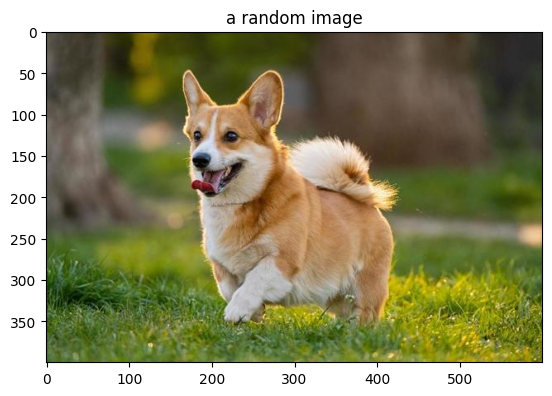

In [23]:
img_index       = 1
img_name        = TEST_IMAGE_DIR + image_name_list[img_index]
img             = PIL.Image.open(img_name)
print(f"[width, height] of the image: [{img.size[0]}, {img.size[1]}]")
plt.imshow(img)
plt.title("a random image")
plt.show()

##**Transform the image by resizing + normalizing it with ImageNet mean**


In [24]:
imagenet_mean, imagenet_std  = get_imagenet_mean_std_normalized()
print(f"ImageNet: mean: {imagenet_mean}, std: {imagenet_std}")


TEST_IMAGE_SIZE_W   = 227
TEST_IMAGE_SIZE_H   = 227

# CNN architectures such as AlexNet, VGGNet, and ResNet has been pre-trained using the ImageNet dataset.
# You need to normalize each image with the given mean and standard deviation before doing the forward-pass on these networks.
transform = transforms.Compose([
    transforms.Resize((TEST_IMAGE_SIZE_W, TEST_IMAGE_SIZE_H)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std) # ImageNet: mean (R, G, B) and standard deviation (R, G, B)
])

img_transformed          = transform(img).unsqueeze(0).to(device)
print(f"Convert the image into PyTorch tensor after normalization: ...")
print(f"image tensor shape: {img_transformed.shape}") # [HOW_MANY_TENSORS, CHANNEL_SIZE, HEIGHT, WIDTH]
print(f"{"HOW_MANY_TENSORS:":<20} {img_transformed.shape[0]}")
print(f"{"CHANNEL_SIZE:":<20} {img_transformed.shape[1]}")
print(f"{"HEIGHT_SIZE:":<20} {img_transformed.shape[2]}")
print(f"{"WIDTH_SIZE:":<20} {img_transformed.shape[3]}")
print(f"Summary: [how_many, channel, height, width] of the image tensor: {img_transformed.shape[0]}x{img_transformed.shape[1]}x{img_transformed.shape[2]}x{img_transformed.shape[3]}")




ImageNet: mean: [0.485, 0.456, 0.406], std: [0.229, 0.224, 0.225]
Convert the image into PyTorch tensor after normalization: ...
image tensor shape: torch.Size([1, 3, 227, 227])
HOW_MANY_TENSORS:    1
CHANNEL_SIZE:        3
HEIGHT_SIZE:         227
WIDTH_SIZE:          227
Summary: [how_many, channel, height, width] of the image tensor: 1x3x227x227


## **Perform a forward pass of the input volume through your ResNet.**

In [25]:
# forward pass the transformed image through your CNN network
model.eval()
raw_output = model(img_transformed)
output_prob = torch.softmax( raw_output, dim=1 )
display_prediction(output_prob, label_map, how_many=7)

shape of input:  torch.Size([1, 3, 227, 227])
output shape (self.avgpool):  torch.Size([1, 512, 1, 1])
output shape (self.fc):  torch.Size([1, 1000])
label map: {'0': 'tench, Tinca tinca', '1': 'goldfish, Carassius auratus', '2': 'great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias', '3': 'tiger shark, Galeocerdo cuvieri', '4': 'hammerhead, hammerhead shark', '5': 'electric ray, crampfish, numbfish, torpedo', '6': 'stingray', '7': 'cock', '8': 'hen', '9': 'ostrich, Struthio camelus', '10': 'brambling, Fringilla montifringilla', '11': 'goldfinch, Carduelis carduelis', '12': 'house finch, linnet, Carpodacus mexicanus', '13': 'junco, snowbird', '14': 'indigo bunting, indigo finch, indigo bird, Passerina cyanea', '15': 'robin, American robin, Turdus migratorius', '16': 'bulbul', '17': 'jay', '18': 'magpie', '19': 'chickadee', '20': 'water ouzel, dipper', '21': 'kite', '22': 'bald eagle, American eagle, Haliaeetus leucocephalus', '23': 'vulture', '24': 'great

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


input image.shape=torch.Size([1, 3, 227, 227])
shape of input:  torch.Size([1, 3, 227, 227])
output shape (self.avgpool):  torch.Size([1, 512, 1, 1])
output shape (self.fc):  torch.Size([1, 1000])
label map: {'0': 'tench, Tinca tinca', '1': 'goldfish, Carassius auratus', '2': 'great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias', '3': 'tiger shark, Galeocerdo cuvieri', '4': 'hammerhead, hammerhead shark', '5': 'electric ray, crampfish, numbfish, torpedo', '6': 'stingray', '7': 'cock', '8': 'hen', '9': 'ostrich, Struthio camelus', '10': 'brambling, Fringilla montifringilla', '11': 'goldfinch, Carduelis carduelis', '12': 'house finch, linnet, Carpodacus mexicanus', '13': 'junco, snowbird', '14': 'indigo bunting, indigo finch, indigo bird, Passerina cyanea', '15': 'robin, American robin, Turdus migratorius', '16': 'bulbul', '17': 'jay', '18': 'magpie', '19': 'chickadee', '20': 'water ouzel, dipper', '21': 'kite', '22': 'bald eagle, American eagle, Haliaeetu

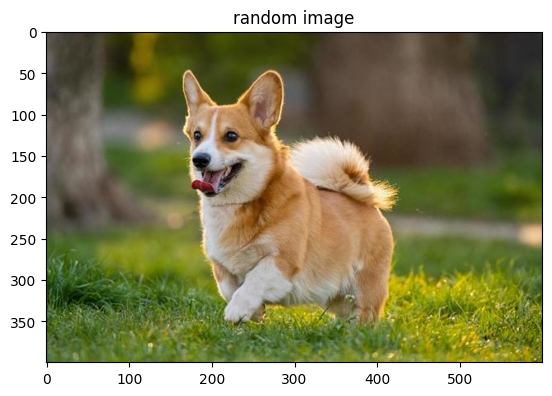

In [21]:
# ------------------------Make a class the load pretrained weights of the CNN------------------------------------------------
num_of_classes = 1000
model = ResNet(num_of_classes)
model.to(device)

# ------------------------Read an image using PIL------------------------------------------------
img_index       = 1
img_name        = TEST_IMAGE_DIR + '/' + image_name_list[img_index]
img = PIL.Image.open(img_name)
plt.imshow(img)
plt.title("random image")

# ------------------------Transform the image by resizing + normalizing -------------------------
imagenet_mean, imagenet_std = get_imagenet_mean_std_normalized()
my_transform = transforms.Compose(
    [ transforms.Resize( (227, 227) ),
      transforms.ToTensor(),
      transforms.Normalize(mean=imagenet_mean, std=imagenet_std)]
)
img_transformed = my_transform(img).unsqueeze(0).to(device)
print(f"input image.shape={img_transformed.shape}")

# ------------------------Apply forward pass through your CNN-----------------------------------------
model.eval()
raw_output = model(img_transformed)
output_prob = torch.softmax( raw_output, dim=1 )
display_prediction(output_prob, label_map, how_many=7)